# Netflix Data Analysis 

**Name:**Sakshi
**Subject:**Data Visualization
**Faculty:**Ankit Verma
**Course:**BCA-DS-AI
**Batch:**BCADS15
**University Roll No:**1250258382

In [1]:
#Import liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df=pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Basic Dataset Exploration
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
# Insight:
# a. Dataset contains Netflix Movies and TV Shows information.
# b. Columns include title, cast, director, country, genre, release year etc.

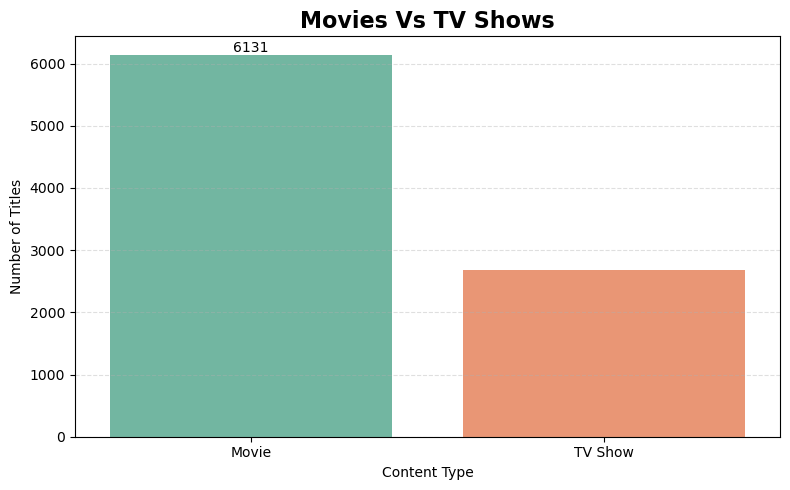

<Figure size 640x480 with 0 Axes>

In [5]:
#1.Movies VS TV Shows Ratio
plt.figure(figsize=(8,5))
ax=sns.countplot(
    x='type',
    data=df,
    hue='type',
    palette='Set2',
    legend=False)
plt.title("Movies Vs TV Shows",
         fontsize=16,
         fontweight='bold')
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.grid(axis='y',linestyle='--',alpha=0.4)

for container in ax.containers:
    ax.bar_label(container)
    plt.tight_layout()
    plt.show()


In [6]:
# Insight:
# Netflix contains significantly more Movies than TV Shows.
# Movies dominate the platform because they require less long-term production.

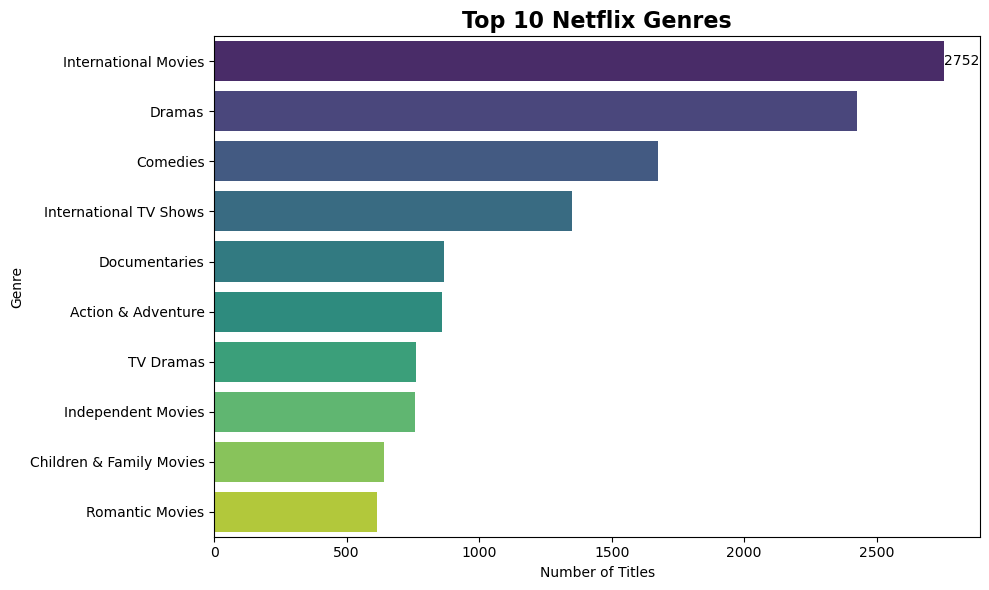

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [7]:
#2.Top 10 Genres
genres=df['listed_in'].str.split(',').explode().str.strip()
top_genres=genres.value_counts().head(10)
plt.figure(figsize=(10,6))
ax=sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="viridis",
    legend=False,
    dodge=False)
plt.title("Top 10 Netflix Genres",
          fontsize=16,
          fontweight='bold')
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
for container in ax.containers:
    ax.bar_label(container)
    plt.tight_layout()
    plt.show()

In [8]:
# Insights:
# a. Drama, International Movies and Comedy dominate Netflix.
# b. These genres attract global audiences.

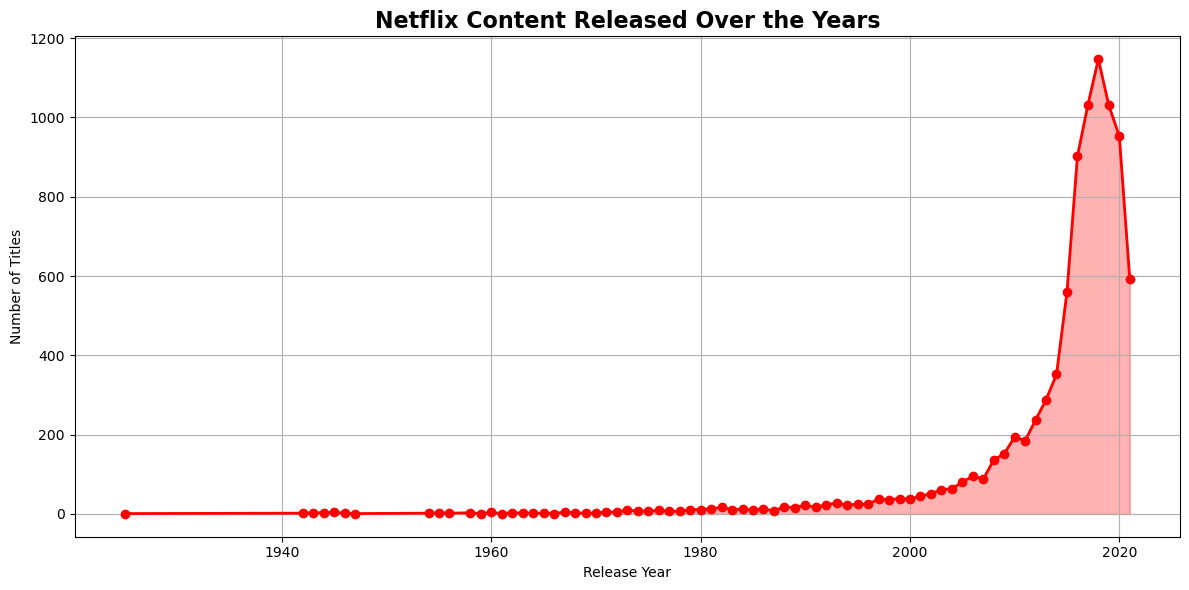

In [9]:
#3.Content Released by Year
release = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(
    release.index,
    release.values,
    marker='o',
    linewidth=2,
    color='red')

plt.fill_between(
    release.index,
    release.values,
    alpha=0.3,
    color='red'
)
plt.title("Netflix Content Released Over the Years",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
#Insights:
# Netflix content production increased rapidly after 2015.
# The platform expanded significantly in recent years.

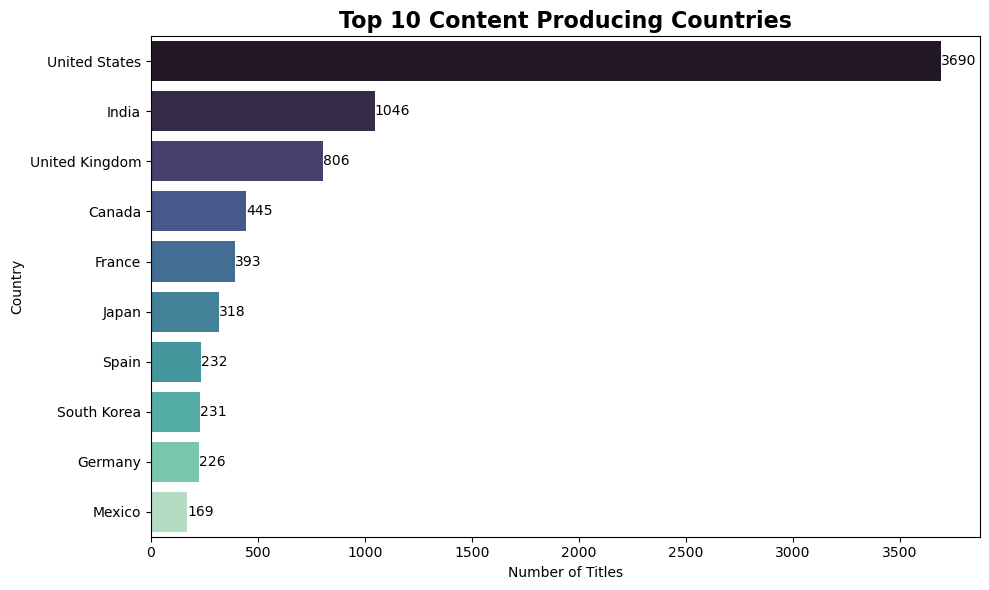

In [11]:
#4.Top Content Producing Countries
country = df['country'].dropna().str.split(',').explode().str.strip()

top_country = country.value_counts().head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_country.values,
    y=top_country.index,
    hue=top_country.index,
    palette="mako",
    legend=False,
    dodge=False
)

plt.title("Top 10 Content Producing Countries",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Number of Titles")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [12]:
# Insight:
# The United States is the leading content producer.
# India and the United Kingdom are also major contributors.

In [13]:
# 5. Content Added to Netflix Over Time
# Convert date_added into datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Create a new column containing only the year
df['year_added'] = df['date_added'].dt.year
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='object')


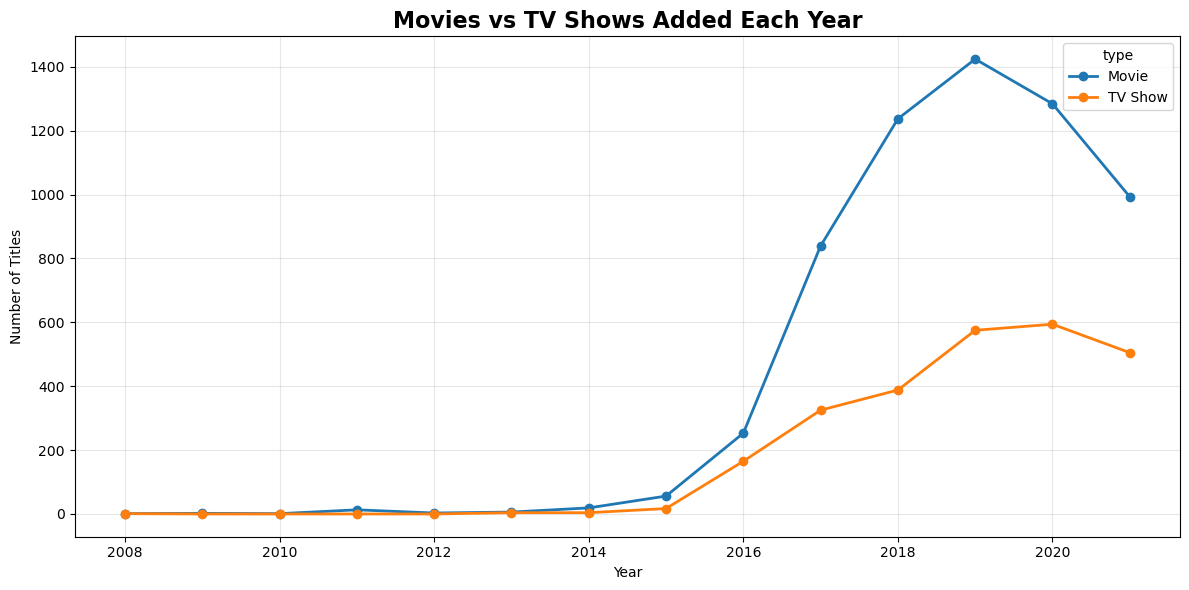

In [14]:
year_type = pd.crosstab(df['year_added'], df['type'])

year_type.plot(
    figsize=(12,6),
    marker='o',
    linewidth=2
)

plt.title("Movies vs TV Shows Added Each Year", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Insight:
# Both movies and TV shows increased steadily until around 2019–2020, with movies consistently being added in larger numbers.

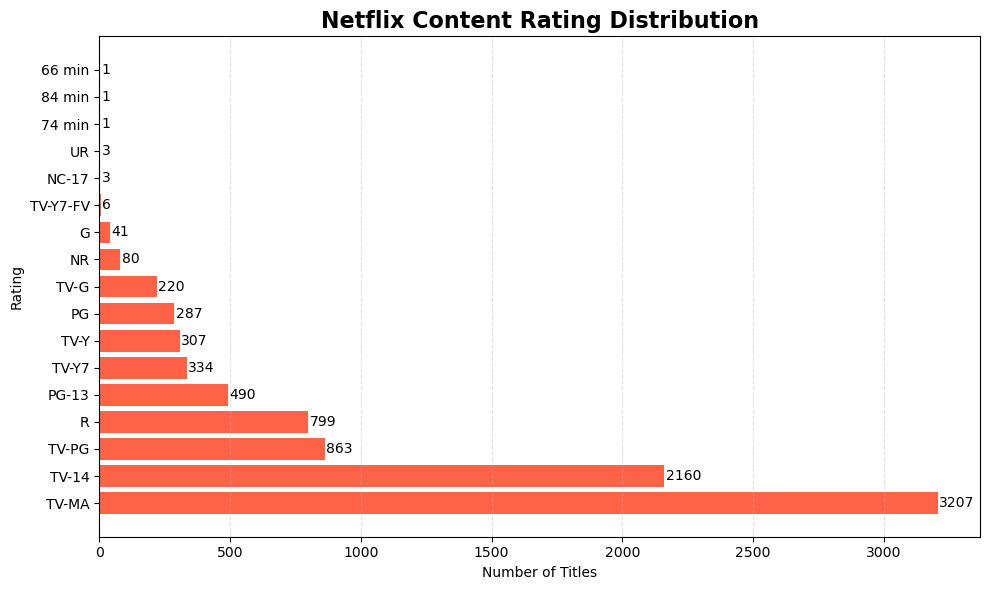

In [16]:
# 6. Rating Distribution
rating = df['rating'].dropna().value_counts()

plt.figure(figsize=(10,6))

bars = plt.barh(
    rating.index,
    rating.values,
    color='tomato'
)

plt.title("Netflix Content Rating Distribution",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Number of Titles")
plt.ylabel("Rating")

for bar in bars:
    plt.text(bar.get_width()+5,
             bar.get_y()+bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [17]:
# Insight:
# TV-MA is the most common rating.
# Netflix mainly targets mature audiences.

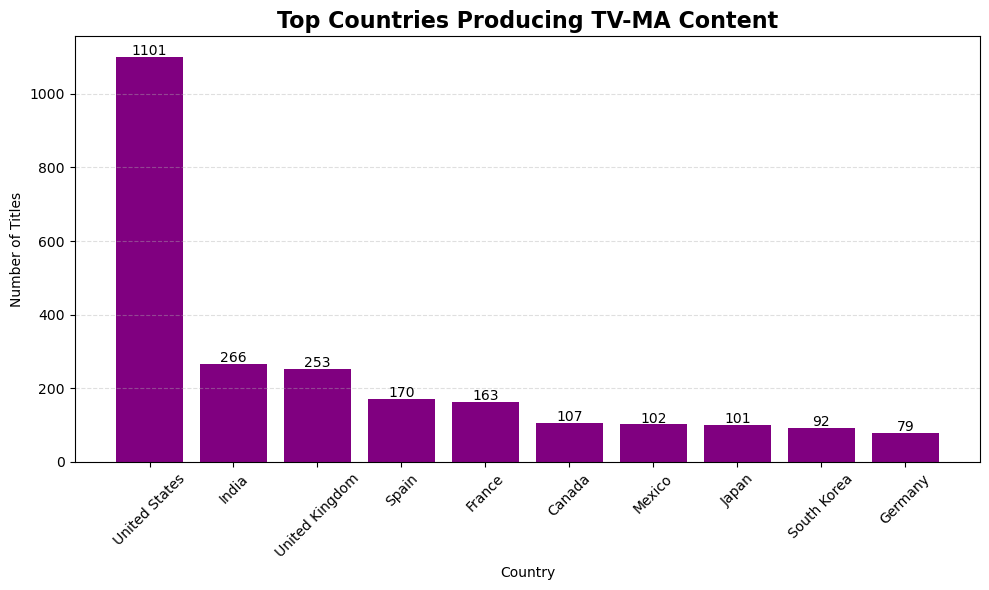

In [18]:
# 7.TV-MA Content by Country
adult = df[df['rating']=='TV-MA']

country = adult['country'].dropna().str.split(',').explode().str.strip()

top_country = country.value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.bar(
    top_country.index,
    top_country.values,
    color='purple'
)

plt.title("Top Countries Producing TV-MA Content",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+5,
             int(bar.get_height()),
             ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [19]:
# Insight:
# The United States produces the highest amount of mature-rated content.

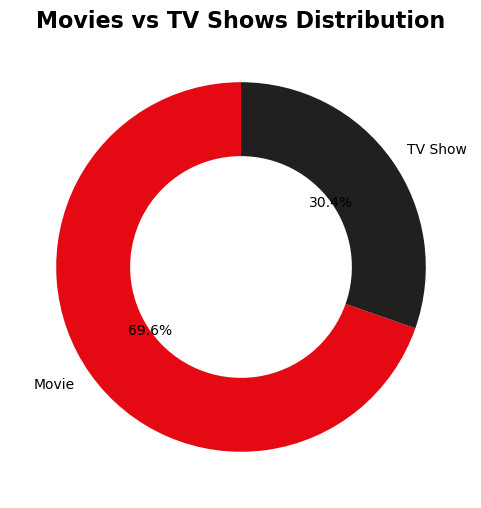

In [20]:
# 8. Movies VS TV Shows
content = df['type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    content,
    labels=content.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4},
    colors=['#E50914','#221F1F']
)

plt.title("Movies vs TV Shows Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

In [21]:
# Insight:
# Movies account for the majority of Netflix's catalog

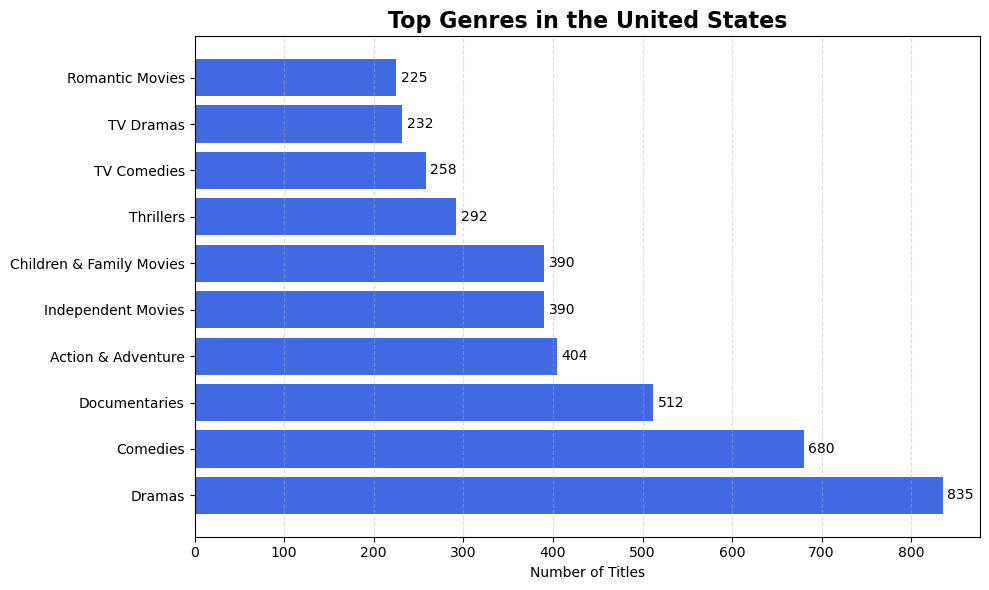

In [45]:
#9.Top Genres in the United States
usa = df[df['country'].str.contains("United States", na=False)]

genres = usa['listed_in'].str.split(',').explode().str.strip()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_genres.index,
    top_genres.values,
    color='royalblue'
)

plt.title("Top Genres in the United States",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Number of Titles")

for bar in bars:
    plt.text(bar.get_width()+5,
             bar.get_y()+bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [23]:
# Insight:
# Drama and Documentaries are especially popular in the United States.

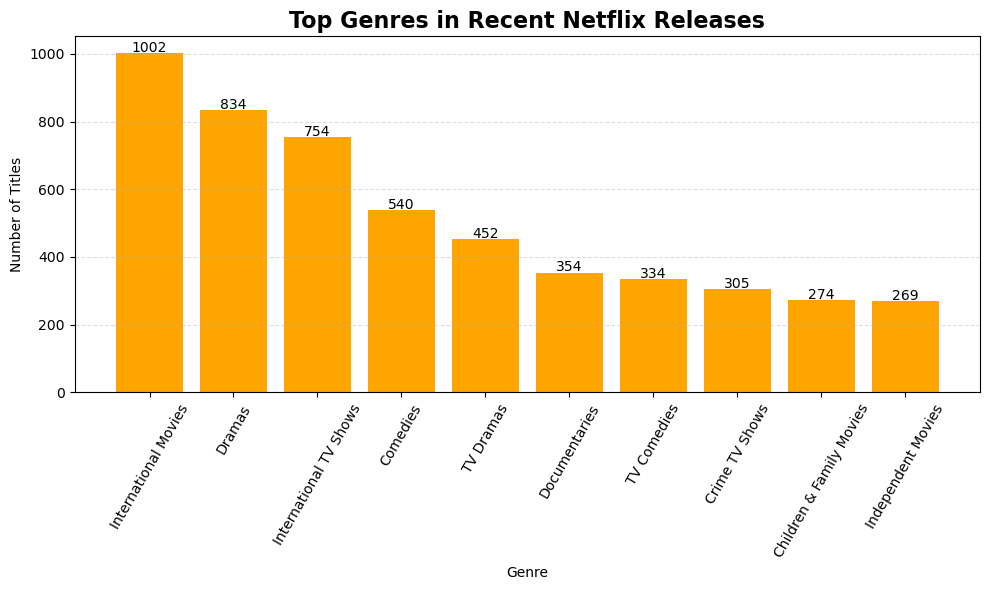

In [24]:
#10.Recent Top Genres(Later 3 Years)
recent = df[df['release_year'] >= df['release_year'].max()-3]

genres = recent['listed_in'].str.split(',').explode().str.strip()

top_recent = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.bar(
    top_recent.index,
    top_recent.values,
    color='orange'
)

plt.title("Top Genres in Recent Netflix Releases",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=60)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+3,
             int(bar.get_height()),
             ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [25]:
# Insight:
# International Movies, Drama, and Comedy remain dominant among the most recent Netflix releases.

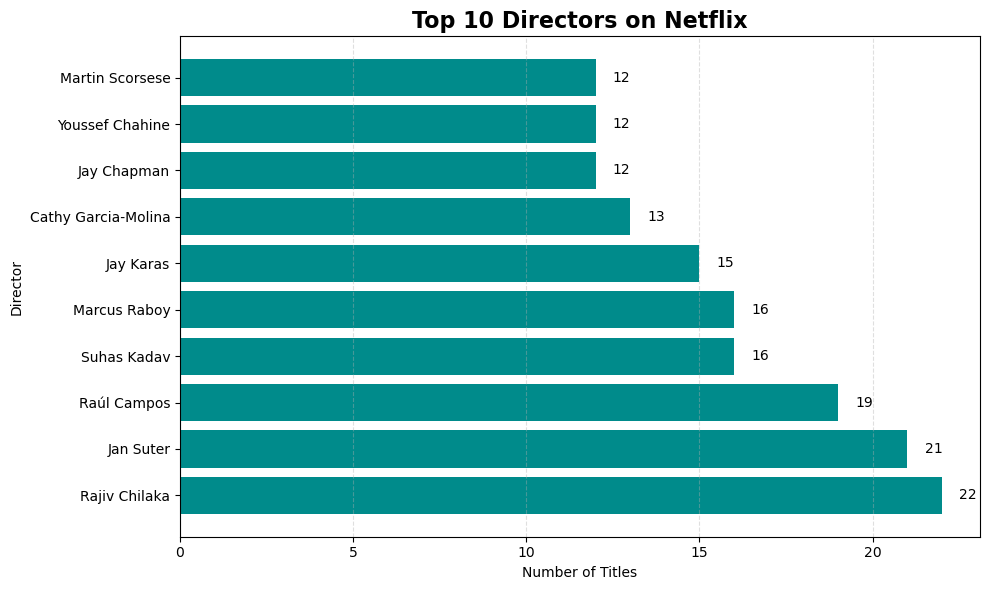

In [26]:
#11.Top Directors on Netflix
directors = df['director'].dropna().str.split(',').explode().str.strip()

top_directors = directors.value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_directors.index,
    top_directors.values,
    color='darkcyan'
)

plt.title("Top 10 Directors on Netflix", fontsize=16, fontweight='bold')
plt.xlabel("Number of Titles")
plt.ylabel("Director")

for bar in bars:
    plt.text(bar.get_width()+0.5,
             bar.get_y()+bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [27]:
# Insight:
# A few directors have contributed a large number of titles, indicating long-term collaborations with Netflix.

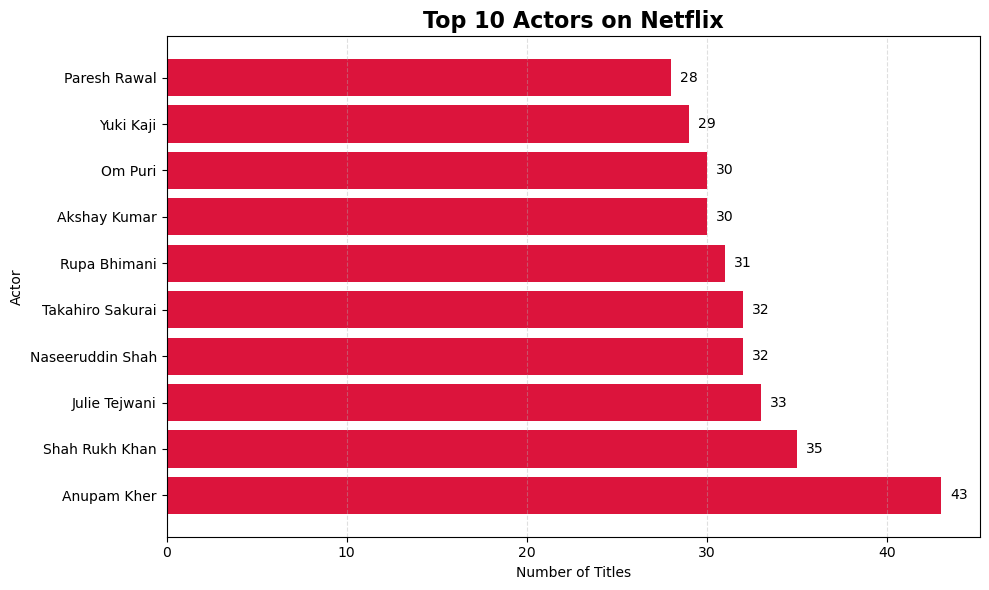

In [28]:
#12.Top Actors on Netflix
actors = df['cast'].dropna().str.split(',').explode().str.strip()

top_actors = actors.value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_actors.index,
    top_actors.values,
    color='crimson'
)

plt.title("Top 10 Actors on Netflix", fontsize=16, fontweight='bold')
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

for bar in bars:
    plt.text(bar.get_width()+0.5,
             bar.get_y()+bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [29]:
# Insight:
# Some actors appear in many Netflix productions, showing strong partnerships with the platform.

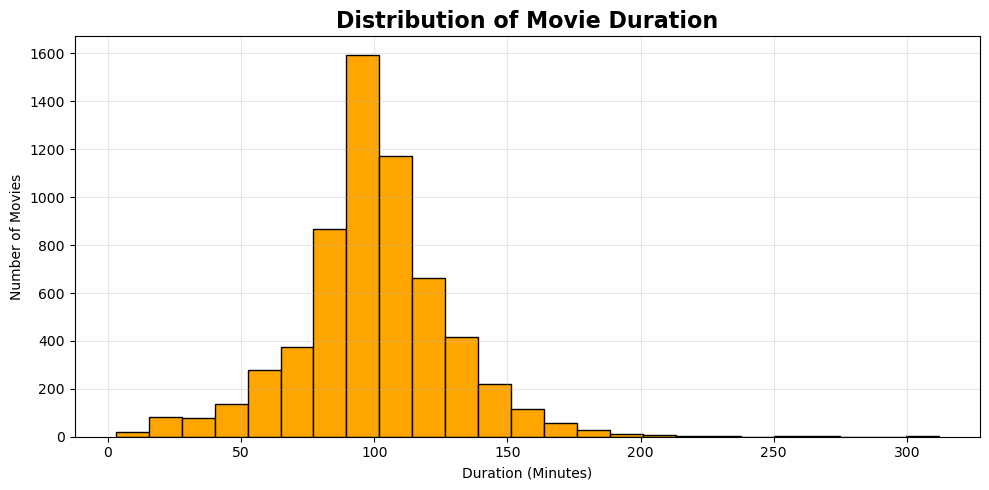

In [30]:
#13.Movie Duration Distribution
movies = df[df['type']=="Movie"].copy()

movies['duration'] = movies['duration'].str.replace(" min","", regex=False)
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

plt.figure(figsize=(10,5))

plt.hist(
    movies['duration'].dropna(),
    bins=25,
    color='orange',
    edgecolor='black'
)

plt.title("Distribution of Movie Duration", fontsize=16, fontweight='bold')
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Insight:
# Most Netflix movies have durations between 80 and 120 minutes.

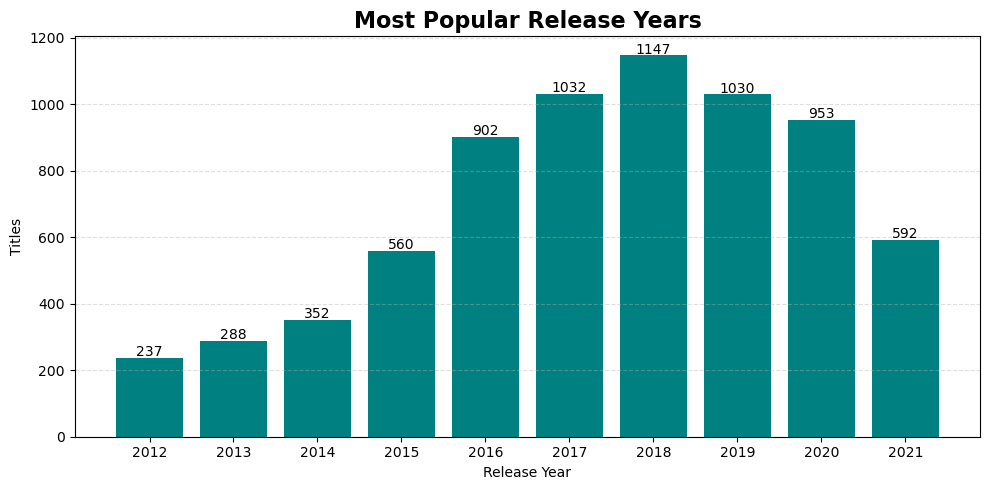

In [32]:
#14.Top 10 Release Year
release = df['release_year'].value_counts().head(10).sort_index()

plt.figure(figsize=(10,5))

bars = plt.bar(
    release.index.astype(str),
    release.values,
    color='teal'
)

plt.title("Most Popular Release Years", fontsize=16, fontweight='bold')
plt.xlabel("Release Year")
plt.ylabel("Titles")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+5,
             int(bar.get_height()),
             ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [33]:
# Insight:
# Recent years dominate Netflix's catalog, reflecting its focus on modern content.

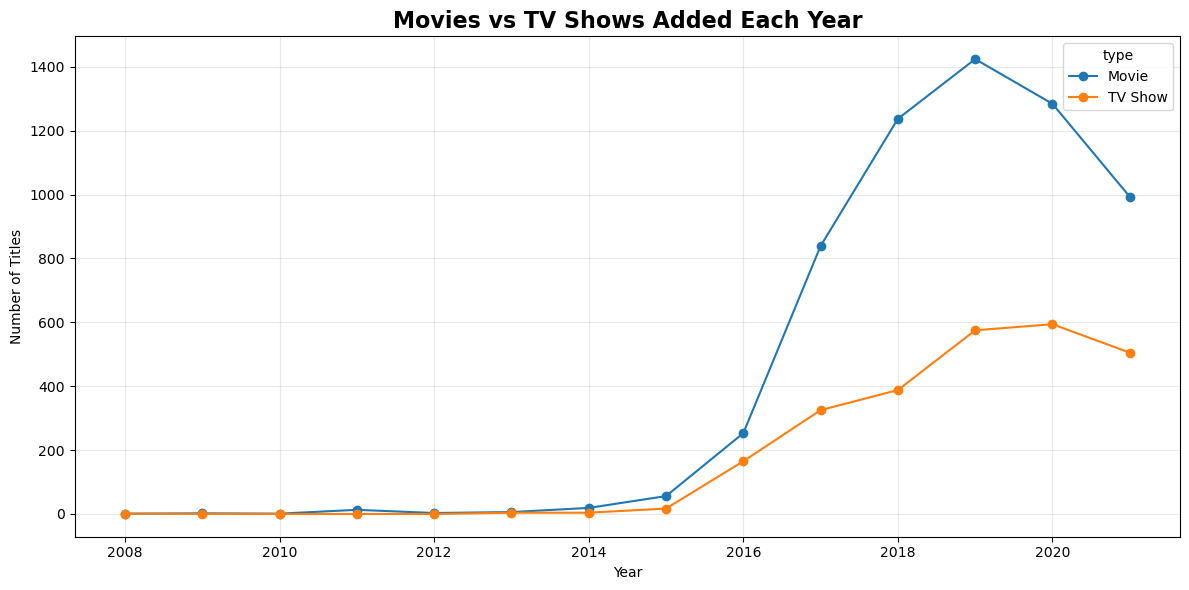

In [34]:
#15.Movies VS TV Shows Added Every Year
year_type = pd.crosstab(df['year_added'], df['type'])

year_type.plot(
    figsize=(12,6),
    marker='o'
)

plt.title("Movies vs TV Shows Added Each Year", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Insight:
# Both movies and TV shows increased steadily until around 2019–2020, with movies consistently being added in larger numbers.

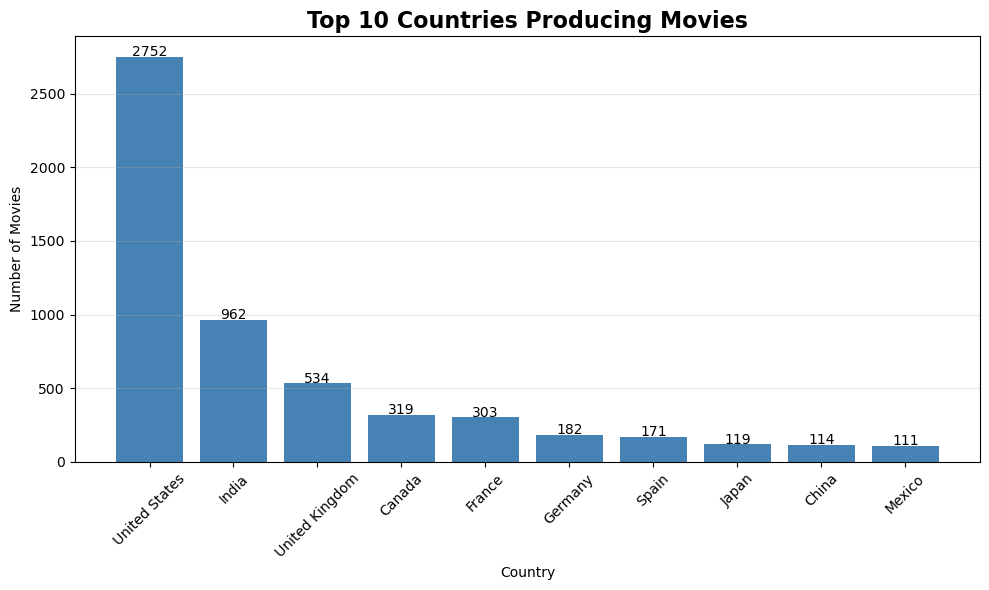

In [36]:
# 16. Top 10 Countries Producing Movies
movies = df[df['type'] == 'Movie']

country = movies['country'].dropna().str.split(',').explode().str.strip()

top_country = country.value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.bar(top_country.index,
               top_country.values,
               color='steelblue')

plt.title("Top 10 Countries Producing Movies",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Country")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+5,
             int(bar.get_height()),
             ha='center')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Insight:
#The United States produces the largest number of TV Shows on Netflix.

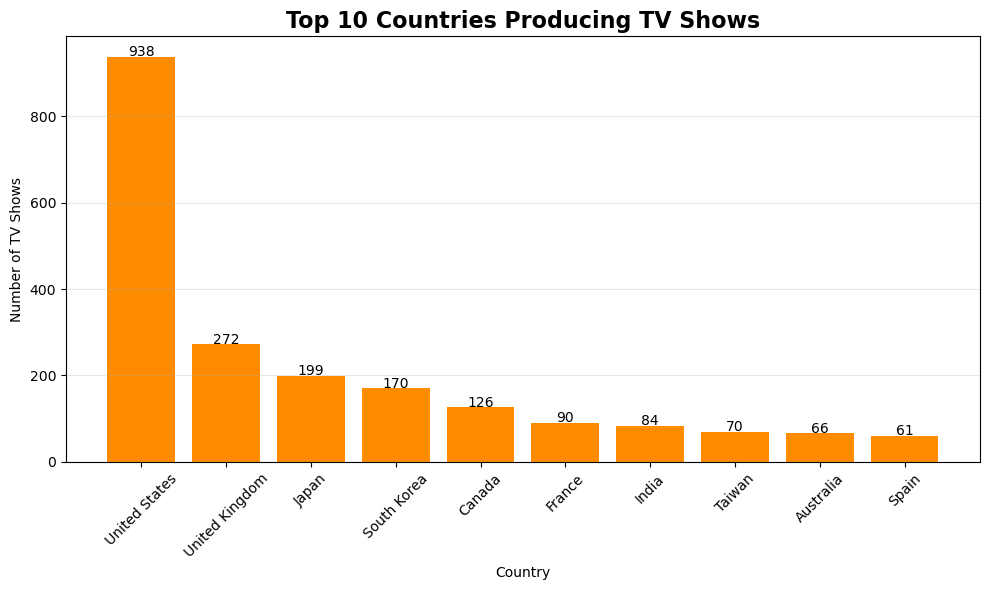

In [38]:
#17.Top 10 Countries Producing TV Shows
tv = df[df['type'] == 'TV Show']

country = tv['country'].dropna().str.split(',').explode().str.strip()

top_country = country.value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.bar(top_country.index,
               top_country.values,
               color='darkorange')

plt.title("Top 10 Countries Producing TV Shows",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Country")
plt.ylabel("Number of TV Shows")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+2,
             int(bar.get_height()),
             ha='center')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
# Insight:
# The United States and several Asian countries contribute significantlly to Netflix TV shows

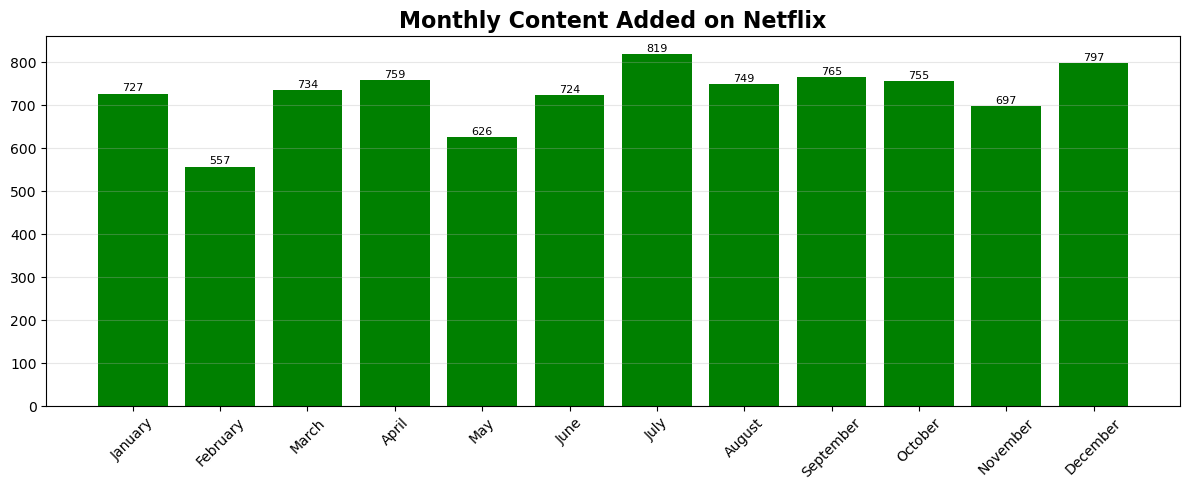

In [40]:
#18.Monthly Content Addition Trend
df['month_added'] = df['date_added'].dt.month_name()

months = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly = df['month_added'].value_counts().reindex(months)

plt.figure(figsize=(12,5))

bars = plt.bar(monthly.index,
               monthly.values,
               color='green')

plt.title("Monthly Content Added on Netflix",
          fontsize=16,
          fontweight='bold')

plt.xticks(rotation=45)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+5,
             int(bar.get_height()),
             ha='center',
             fontsize=8)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# Insight:
# The Netflix Adds content throughout the year, with some months having noticeably higher releases.

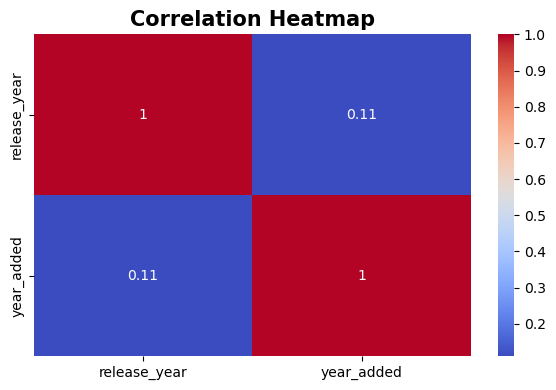

In [42]:
#19.Correlation Heatmap
numeric = df[['release_year','year_added']].dropna()

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap",
          fontsize=15,
          fontweight='bold')

plt.tight_layout()
plt.show()

In [43]:
# Insight:
# There is a positive relationship between release year and thr year content was added to Netflix

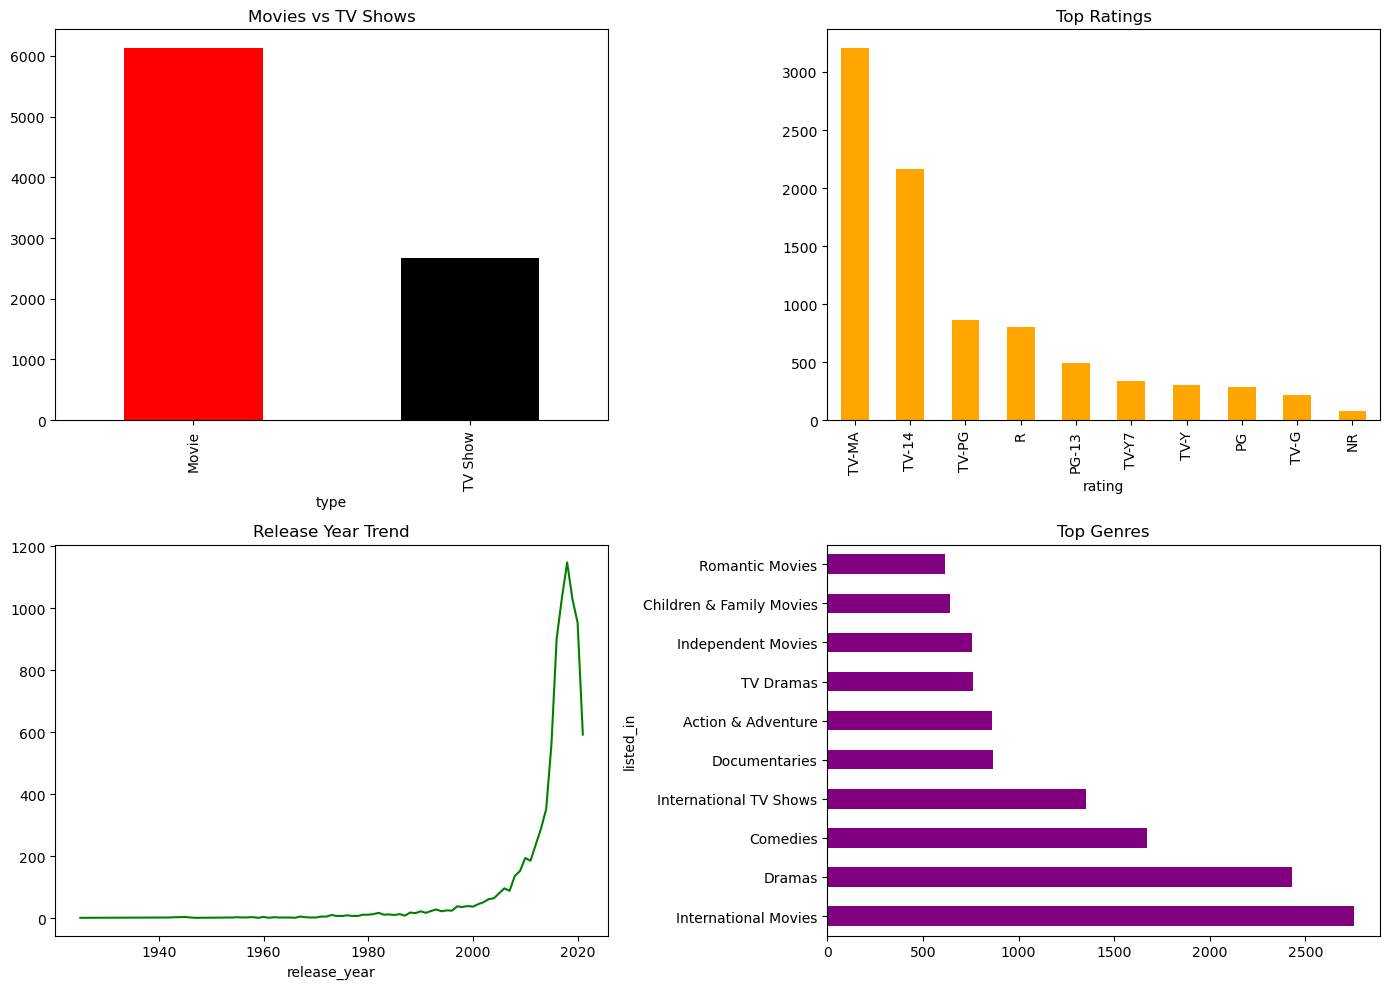

In [44]:
#20. Final Dashboard
fig, axes = plt.subplots(2,2, figsize=(14,10))

# Movies vs TV Shows
df['type'].value_counts().plot(
    kind='bar',
    ax=axes[0,0],
    color=['red','black']
)
axes[0,0].set_title("Movies vs TV Shows")

# Ratings
df['rating'].value_counts().head(10).plot(
    kind='bar',
    ax=axes[0,1],
    color='orange'
)
axes[0,1].set_title("Top Ratings")

# Release Trend
df['release_year'].value_counts().sort_index().plot(
    ax=axes[1,0],
    color='green'
)
axes[1,0].set_title("Release Year Trend")

# Top Genres
genres = df['listed_in'].str.split(',').explode().str.strip()
genres.value_counts().head(10).plot(
    kind='barh',
    ax=axes[1,1],
    color='purple'
)
axes[1,1].set_title("Top Genres")

plt.tight_layout()
plt.show()